# Objetivo, Contexto e Hipóteses

# Carregamento de Dados e Entendimento Inicial

* Carregamento de bibliotecas

In [1]:
# ==============================================================================
# 1. MANIPULAÇÃO DE DADOS E UTILITÁRIOS
# ==============================================================================
import numpy as np
import pandas as pd

# ==============================================================================
# 2. VISUALIZAÇÃO E EXPLICABILIDADE
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Inicializar JS para SHAP interativo
shap.initjs()

# ==============================================================================
# 3. PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES
# ==============================================================================
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==============================================================================
# 4. MODELAGEM E TUNING
# ==============================================================================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import (
    train_test_split, 
    RandomizedSearchCV
)

# ============================================================
# 5. Algoritmos de clustering
# ============================================================
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# ==============================================================================
# 5. MÉTRICAS E DIAGNÓSTICOS ESTATÍSTICOS
# ==============================================================================
from scipy import stats
from scipy.stats import randint, uniform, jarque_bera
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    mean_absolute_percentage_error,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [2]:
# Carregar o dataset
df=fetch_california_housing(as_frame=True).frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


* Legendas de classe

* Entendimento inicial

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
linhas, colunas = df.shape
print(f'Linhas: {linhas}, colunas: {colunas}')

Linhas: 20640, colunas: 9


In [5]:
# Valores faltantes
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [6]:
print(f'Valores duplicados: {df.duplicated().sum()}')

Valores duplicados: 0


* Classificação das variáveis

In [7]:
cols_num = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population",
            "AveOccup", "Latitude", "Longitude"]   # "Latitute", "Longitude" devem ser tratadas com muita atenção!

target = "MedHouseVal"

* Identificação prévia de potenciais problemas

# Análise Exploratória

* Dataset temporário

In [8]:
df_eda = df.copy()

In [9]:
# Transformações
df_eda["HouseAge_sq"] = df_eda["HouseAge"]**2     # Captura o efeito não lnear da idade sobre o valor da residência
df_eda["Bedroom_Ratio"] = df_eda["AveBedrms"] / df_eda["AveRooms"]    
df_eda["Rooms_per_Person"] = df_eda["AveRooms"] / df_eda["AveOccup"]
df_eda["MedInc_by_AveOccup"] = df_eda["MedInc"] / df_eda["AveOccup"]

* Classificação das variáveis do dataset temporário

In [10]:
cols_num = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population",
            "AveOccup", "Latitude", "Longitude", "HouseAge_sq", 
            "Bedroom_Ratio", "Rooms_per_Person", "MedInc_by_AveOccup"]  

target = "MedHouseVal"

* Visualização Espacial do Valor Médio das Casas

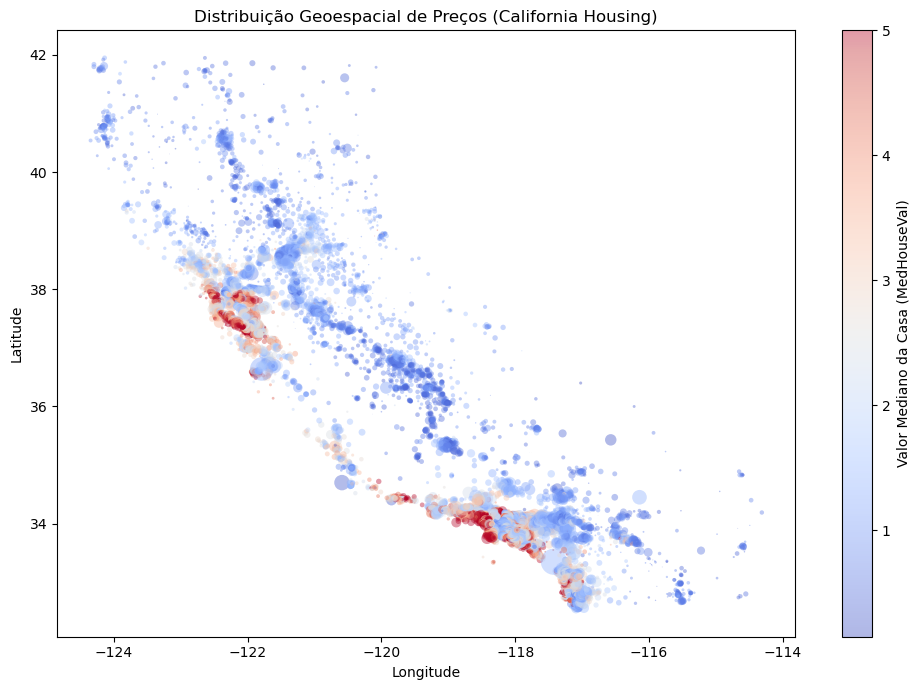

In [11]:
plt.figure(figsize=(10, 7))

# Plotagem
scatter = plt.scatter(
    x=df['Longitude'], 
    y=df['Latitude'], 
    c=df['MedHouseVal'],      # A cor é o Valor da Casa
    s=df['Population']/100,   # (Opcional) O tamanho do ponto é a População
    cmap='coolwarm',          # Azul (barato) -> Vermelho (caro)
    alpha=0.4,                # Transparência é CRUCIAL para ver densidade
    edgecolors='none'         # Remove borda para ficar mais "líquido"
)

plt.colorbar(scatter, label='Valor Mediano da Casa (MedHouseVal)')
plt.title('Distribuição Geoespacial de Preços (California Housing)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.tight_layout()
plt.show()

* Distriuição da variável target

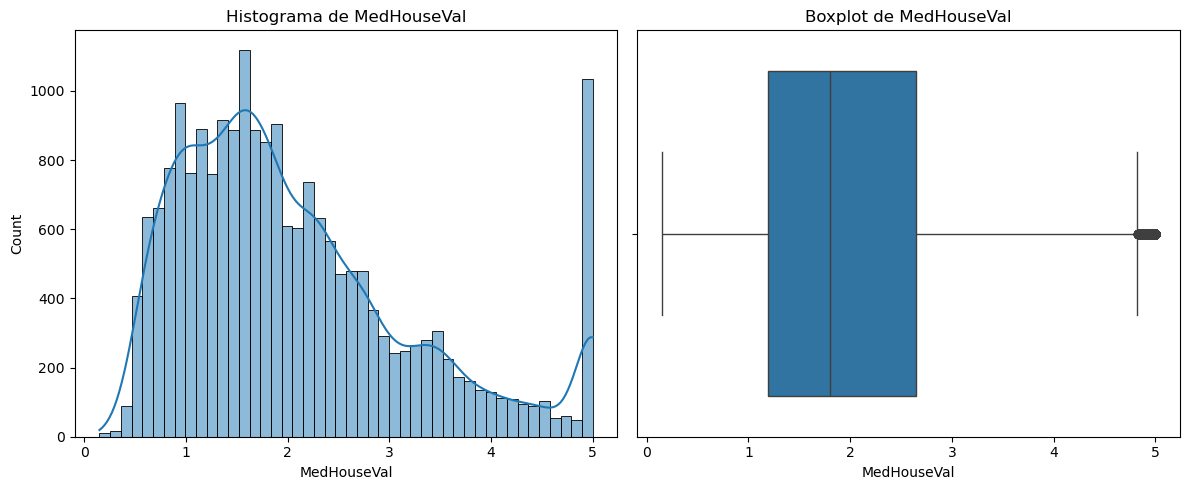

In [12]:
fig, axes = plt.subplots(1, 2, figsize = (12,5))

sns.histplot(data = df_eda, x = target, kde = True, 
             edgecolor = "black", ax = axes[0])

axes[0].set_title(f"Histograma de {target}")

sns.boxplot(data = df_eda, x = target, ax = axes[1])

axes[1].set_title(f"Boxplot de {target}")

plt.tight_layout()
plt.show()

* Distribuição das variáveis numéricas

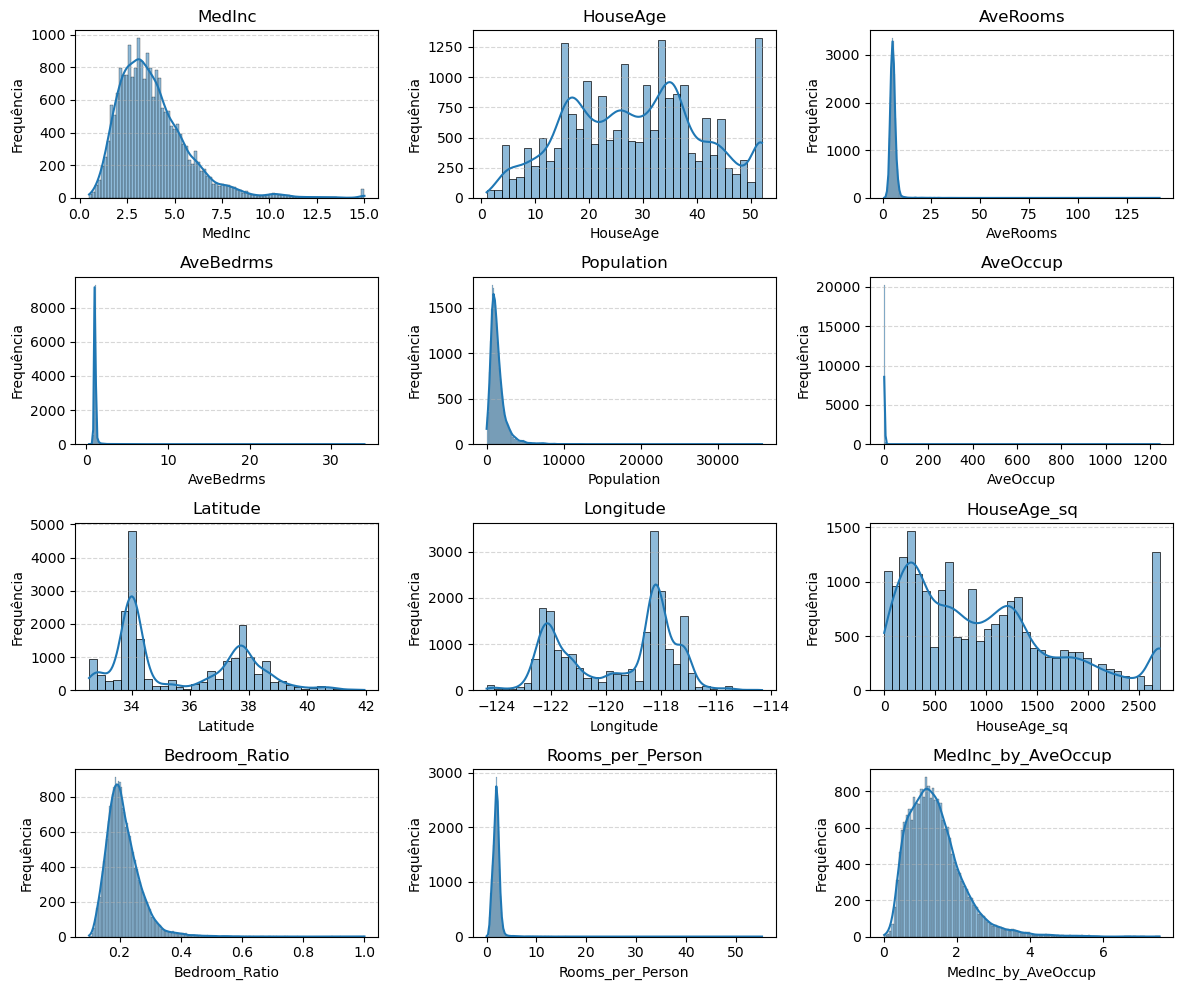

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_num):
    sns.histplot(
        data=df_eda,
        x=col,
        kde=True,
        edgecolor="black",
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

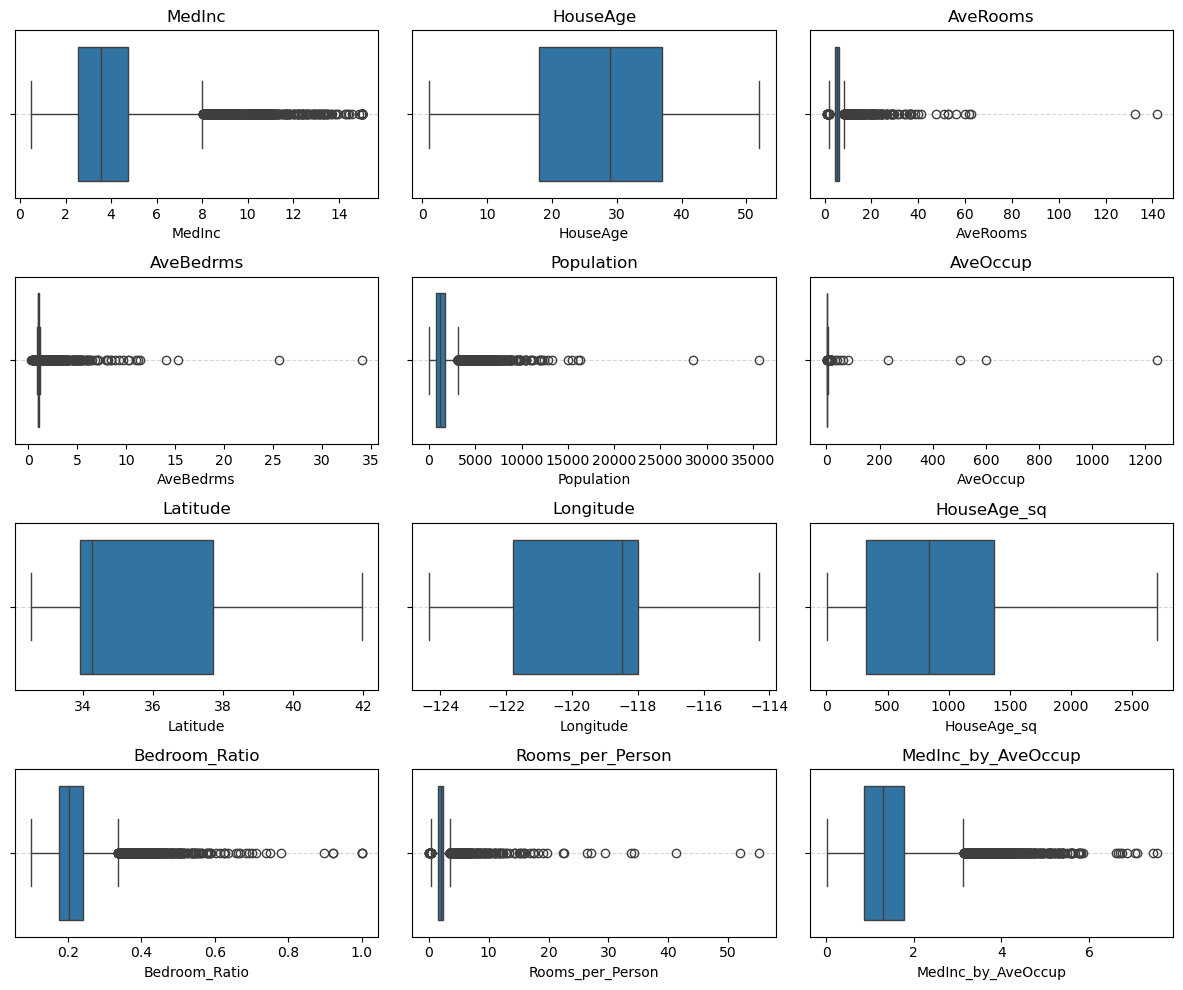

In [14]:
fig, axes = plt.subplots(4,3, figsize=(12,10))
axes = axes.flatten()

for ax, col in zip(axes, cols_num):
    sns.boxplot(data=df_eda, x=col, ax=ax)
    ax.set_title(col)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    
# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as demais numéricas

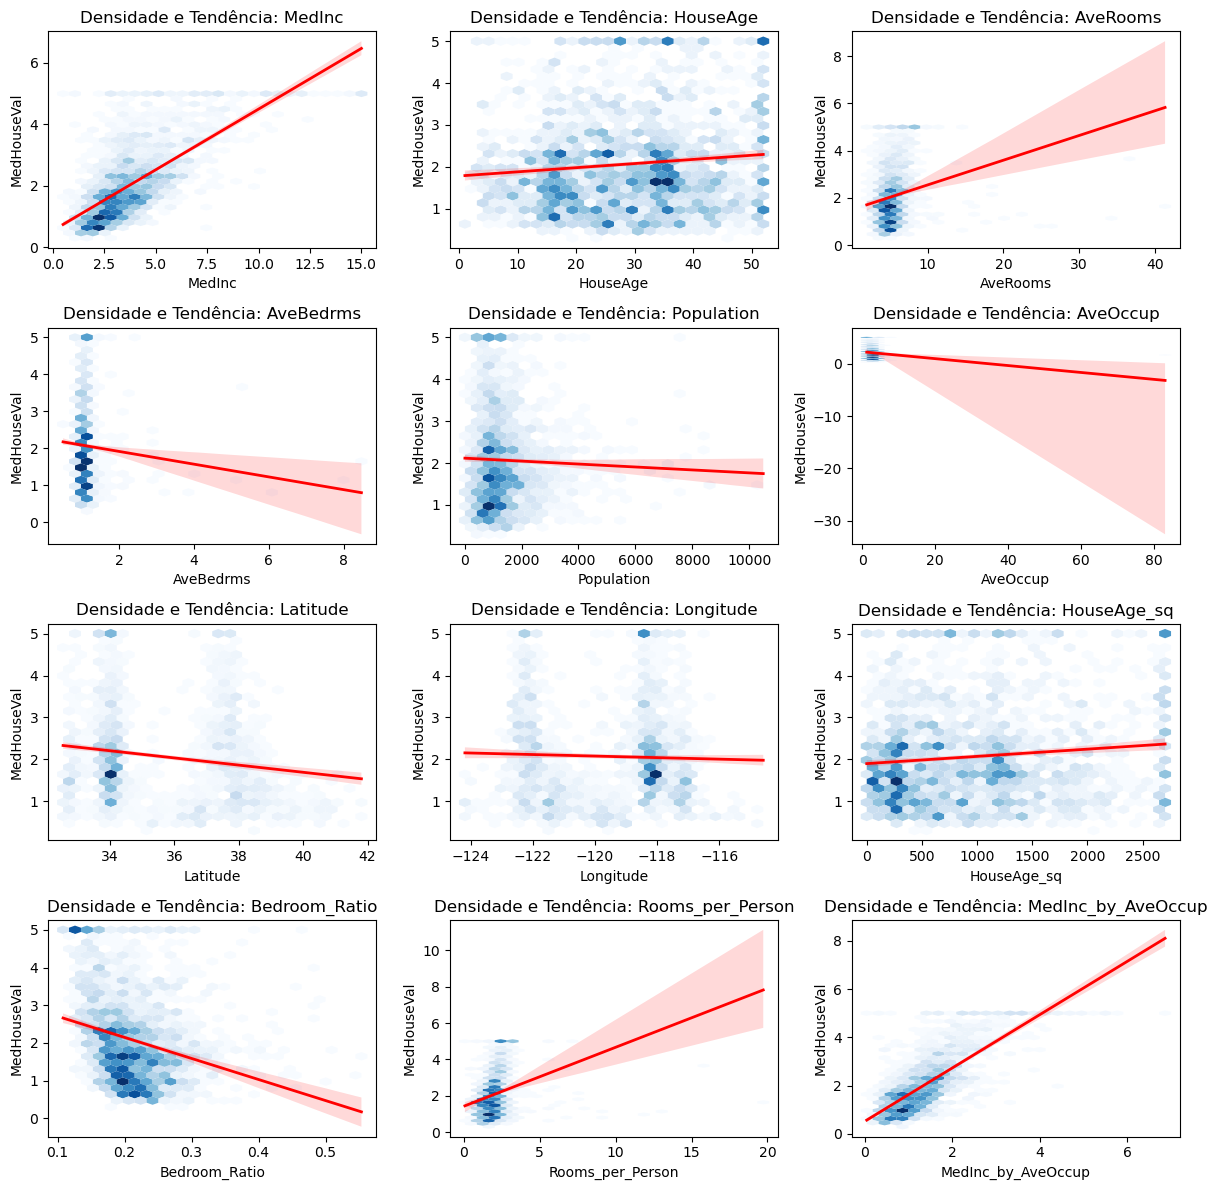

In [15]:
df_viz = df_eda.sample(frac=0.1, random_state=42) 

fig, axes = plt.subplots(4, 3, figsize=(12, 12)) 
axes = axes.flatten()

for ax, col in zip(axes, cols_num):
    
    # 1. O Hexbin (Mostra a Densidade/Nuvem)
    hb = ax.hexbin(
        x=df_viz[col], 
        y=df_viz[target], 
        gridsize=25,       # Tamanho do hexágono (maior = menos detalhe, mais "mancha")
        cmap='Blues',      # Paleta de cores (Azul fica bom com linha vermelha)
        mincnt=1,          # Importante: Oculta hexágonos vazios (fundo branco)
        edgecolors='none'  # Remove as bordas dos hexágonos para ficar mais limpo
    )
    
    # 2. O Regplot (Mostra APENAS a Tendência)
    sns.regplot(
        data=df_viz, 
        x=col, 
        y=target,
        scatter=False,     
        line_kws={"color": "red", "linewidth": 2}, # Estilo da linha
        ax=ax
    )
    
    # Opcional: Adiciona barra de cores pequena em cada gráfico
    # cb = fig.colorbar(hb, ax=ax)
    # cb.set_label('Contagem')

    ax.set_title(f"Densidade e Tendência: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel(target)

# Remove axes vazios se houver
for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Correlação 

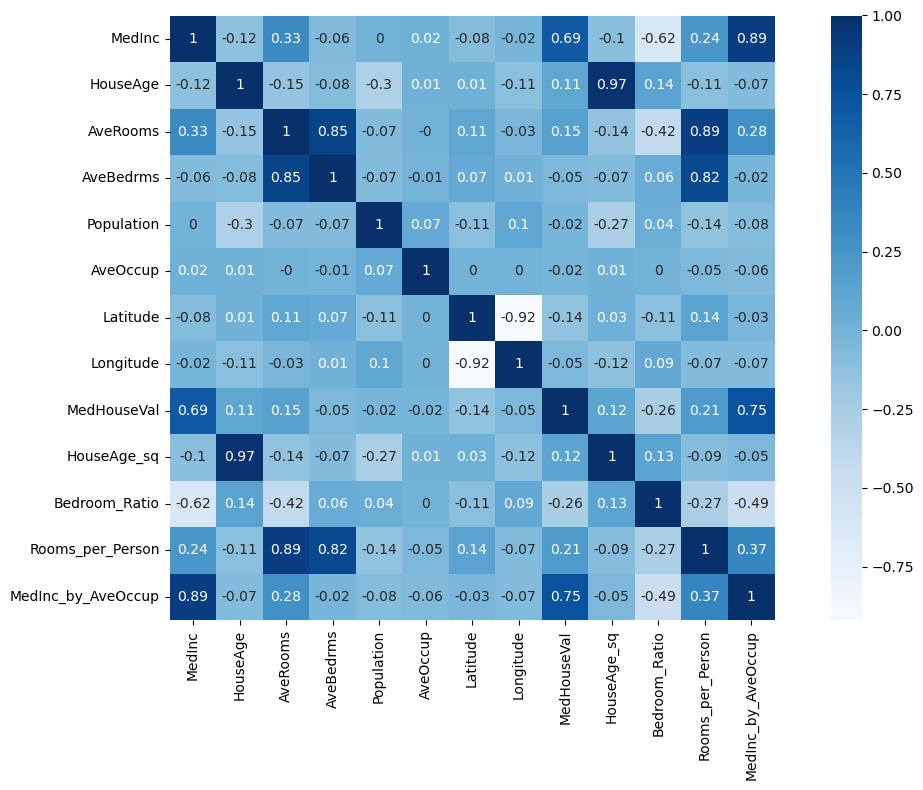

In [17]:
corr = df_eda.corr().round(2)
plt.figure(figsize=(12,8))
sns.heatmap(corr, square=True, annot=True, vmax=1, cmap="Blues")

plt.tight_layout()
plt.show()

# Pré-processamento

* Features irrelevantes

* Dataset de pré-processamento

In [18]:
df_prep = df_eda.copy()

df_prep = df_prep.drop(columns=["Population","AveBedrms", "AveRooms",
                               "AveOccup", "MedInc"]).reset_index(drop=True)

* Separar X e Y

In [19]:
X = df_prep.drop(columns = ["MedHouseVal"])
y = df_prep["MedHouseVal"]

* Clusters e engenharia de feature

In [20]:
cluster_cols = ["Latitude", "Longitude"]

geo_preprocessor = ColumnTransformer(
    transformers=[
        ("geo_scaler", StandardScaler(), cluster_cols)
    ],
    remainder="drop")

In [22]:
def evaluate_geo_clustering(model_name, clustering_pipeline, X_data):

    labels = clustering_pipeline.fit_predict(X_data)

    X_transformed = clustering_pipeline[:-1].transform(X_data)

    # Tratamento especial para DBSCAN
    if -1 in labels:
        valid_labels = labels[labels != -1]
        n_clusters = len(np.unique(valid_labels))
    else:
        n_clusters = len(np.unique(labels))

    if n_clusters <= 1:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan
    else:
        silhouette = silhouette_score(X_transformed, labels)
        davies_bouldin = davies_bouldin_score(
            X_transformed,
            labels
        )
        calinski_harabasz = calinski_harabasz_score(
            X_transformed,
            labels
        )

    return {
        "Modelo": model_name,
        "Silhouette": silhouette,
        "Davies-Bouldin": davies_bouldin,
        "Calinski-Harabasz": calinski_harabasz,
        "n_clusters": n_clusters
    }


In [23]:
cluster_results = []

# ----------------------------------------------------------
# KMeans
# ----------------------------------------------------------

for k in range(20, 50):

    geo_kmeans_pipeline = Pipeline(
        steps=[
            ("preprocess", geo_preprocessor),
            (
                "cluster",
                KMeans(
                    n_clusters=k,
                    random_state=42,
                    n_init=10
                )
            )
        ]
    )

    result = evaluate_geo_clustering(
        model_name=f"KMeans_k={k}",
        clustering_pipeline=geo_kmeans_pipeline,
        X_data=X
    )

    cluster_results.append(result)

# ----------------------------------------------------------
# Gaussian Mixture
# ----------------------------------------------------------

for k in range(20, 50):

    geo_gmm_pipeline = Pipeline(
        steps=[
            ("preprocess", geo_preprocessor),
            (
                "cluster",
                GaussianMixture(
                    n_components=k,
                    random_state=42
                )
            )
        ]
    )

    result = evaluate_geo_clustering(
        model_name=f"GMM_k={k}",
        clustering_pipeline=geo_gmm_pipeline,
        X_data=X
    )

    cluster_results.append(result)

# ----------------------------------------------------------
# Agglomerative
# ----------------------------------------------------------

for k in range(20, 50):

    geo_agglo_pipeline = Pipeline(
        steps=[
            ("preprocess", geo_preprocessor),
            (
                "cluster",
                AgglomerativeClustering(
                    n_clusters=k
                )
            )
        ]
    )

    result = evaluate_geo_clustering(
        model_name=f"Agglo_k={k}",
        clustering_pipeline=geo_agglo_pipeline,
        X_data=X
    )

    cluster_results.append(result)

# ----------------------------------------------------------
# DBSCAN
# ----------------------------------------------------------

geo_dbscan_pipeline = Pipeline(
    steps=[
        ("preprocess", geo_preprocessor),
        (
            "cluster",
            DBSCAN(
                eps=0.7,
                min_samples=10
            )
        )
    ]
)

result = evaluate_geo_clustering(
    model_name="DBSCAN",
    clustering_pipeline=geo_dbscan_pipeline,
    X_data=X
)

cluster_results.append(result)

# ==========================================================
# Ranking dos modelos
# ==========================================================

df_cluster_results = (
    pd.DataFrame(cluster_results)
    .sort_values(
        by="Silhouette",
        ascending=False
    )
)

display(df_cluster_results)

C:\Users\rodri\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\rodri\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\rodri\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rodri\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^

,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters
1,KMeans_k=21,0.468305,0.668622,96448.450395,21
6,KMeans_k=26,0.463575,0.679073,99852.486089,26
7,KMeans_k=27,0.462604,0.677715,99733.213008,27
9,KMeans_k=29,0.461730,0.678485,99264.119358,29
15,KMeans_k=35,0.459293,0.681826,103595.869422,35
...,...,...,...,...,...
53,GMM_k=43,0.347396,1.203619,36602.801160,43
56,GMM_k=46,0.339566,1.195910,31204.652089,46
49,GMM_k=39,0.330570,1.067738,59062.011431,39
48,GMM_k=38,0.321157,1.409139,38906.798167,38


In [24]:
geo_kmeans = Pipeline([
    ("preprocess", geo_preprocessor),
    ("cluster", KMeans(
        n_clusters=21,
        random_state=42,
        n_init=10
    ))
])

geo_cluster = geo_kmeans.fit_predict(X)

In [25]:
X["GeoCluster"] = geo_cluster

In [26]:
# A diferença entre o cluster mais barato e o mais caro é aproximadamente 4x
pd.concat([X, y], axis=1).groupby("GeoCluster")["MedHouseVal"].mean().sort_values()

GeoCluster
18    0.743111
12    0.780318
6     0.826474
3     0.859243
20    0.865335
17    0.883564
13    1.168682
10    1.222405
1     1.257458
0     1.263605
9     1.281961
5     1.388541
14    1.730333
19    1.935922
7     1.967477
4     2.209376
16    2.363609
2     2.587133
8     2.753906
11    2.867445
15    2.956365
Name: MedHouseVal, dtype: float64

* Dividir em treino/teste 

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

* Pré-processador

In [28]:
cols_num = ["HouseAge", "Latitude", "Longitude", "HouseAge_sq",
            "Bedroom_Ratio", "Rooms_per_Person", "MedInc_by_AveOccup"]

cols_cat = ["GeoCluster"]

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cols_cat)
    ],
    remainder="drop"
)

# Treinamento e Avaliação de Modelos Base

* Criar avaliador universal

In [30]:
def evaluate_model(name, model, X_test, y_test):
    
    # Predição
    y_pred = model.predict(X_test)

    # Métricas
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    return {
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

* Pipeline para cada modelo

In [31]:
pipelines = {
    "Linear Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ]),

    "Decision Tree": Pipeline([
        ("preprocess", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=42
        ))
    ]),

    "LGBM": Pipeline([
        ("preprocess", preprocessor),
        ("model", LGBMRegressor(
            random_state=42,
            verbosity=-1
        ))
    ])
}

results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    metrics = evaluate_model(name, pipe, X_test, y_test)
    results.append(metrics)

C:\Users\rodri\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


* Compilar os resultados

In [32]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("RMSE")
df_results

,Modelo,MAE,RMSE,MAPE,R2
3,XGBoost,0.294926,0.451937,0.166117,0.844135
4,LGBM,0.303994,0.463922,0.175086,0.835759
2,Random Forest,0.298125,0.475103,0.165371,0.827747
1,Decision Tree,0.391898,0.630333,0.212810,0.696798
0,Linear Regression,0.454858,0.639111,0.264640,0.688293


# Modelos Promissores

* XGBoost

In [33]:
xgb_param_grid = {
    "model__n_estimators": randint(300, 1200),
    "model__max_depth": randint(3, 12),
    "model__learning_rate": uniform(0.01, 0.2),

    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),

    "model__min_child_weight": randint(1, 15),

    "model__gamma": uniform(0, 5),

    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0, 3)
}

xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': <scipy.stats....00237C199AFD0>, 'model__gamma': <scipy.stats....00237BD9535C0>, 'model__learning_rate': <scipy.stats....00237BFB492B0>, 'model__max_depth': <scipy.stats....00237C199BC50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be t

* LGBM

In [34]:
lgbm_param_grid = {
    "model__n_estimators": randint(300, 1200),
    "model__max_depth": randint(3, 12),
    "model__num_leaves": randint(15, 100),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_samples": randint(5, 50)
}

lgbm_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LGBMRegressor(
        random_state=42,
        verbosity=-1
    ))
])

lgbm_search = RandomizedSearchCV(
    lgbm_pipe,
    param_distributions=lgbm_param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

lgbm_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': <scipy.stats....00237C199F650>, 'model__learning_rate': <scipy.stats....00237C1AFC5A0>, 'model__max_depth': <scipy.stats....00237BD951BA0>, 'model__min_child_samples': <scipy.stats....00237C1AFC490>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits

* Comparação dos modelos promissores

In [35]:
best_models = {
    "XGBoost (Tuned)": xgb_search.best_estimator_,
    "LGBM (Tuned)": lgbm_search.best_estimator_
}

results_tuned = []

for name, model in best_models.items():
    metrics = evaluate_model(name, model, X_test, y_test)
    results_tuned.append(metrics)

df_tuned_results = pd.DataFrame(results_tuned)
df_tuned_results = df_tuned_results.sort_values("RMSE")
df_tuned_results

C:\Users\rodri\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Modelo,MAE,RMSE,MAPE,R2
1,LGBM (Tuned),0.278479,0.434616,0.157618,0.855853
0,XGBoost (Tuned),0.290052,0.450151,0.163686,0.845365


# Análise de Erros e Interpretação do Modelo Final

* Diagnóstico dos resíduos

C:\Users\rodri\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



DIAGNÓSTICO DOS RESÍDUOS

[1] Jarque-Bera — Normalidade dos Resíduos
----------------------------------------------------------------------------------------------------
JB Statistic : 13385.3441
p-value      : 0.000000
Conclusão: Rejeita H₀ → resíduos não seguem normalidade (comum em modelos baseados em árvores).

[2] Estatísticas dos Resíduos
----------------------------------------------------------------------------------------------------
Média      : 0.001996
Mediana    : -0.028363
Desvio Pad.: 0.434664
Mínimo     : -3.436952
Máximo     : 3.455991


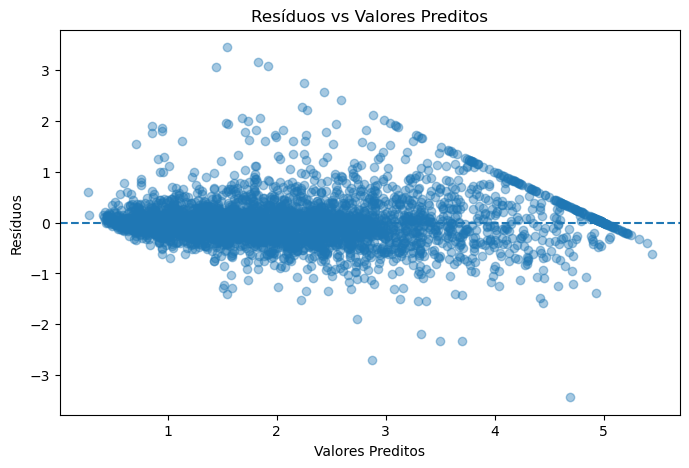

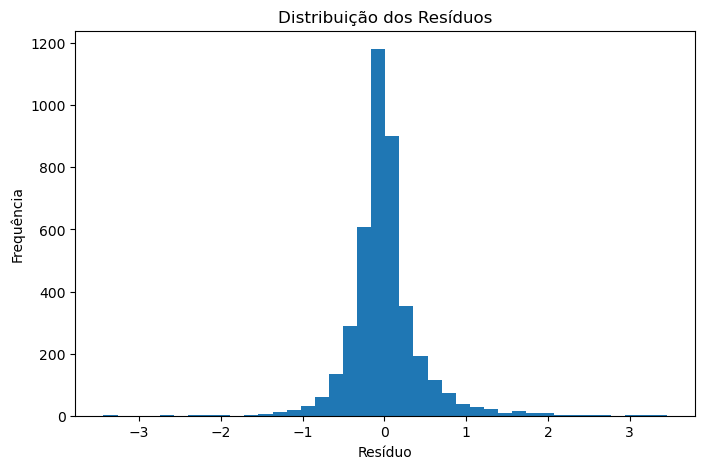

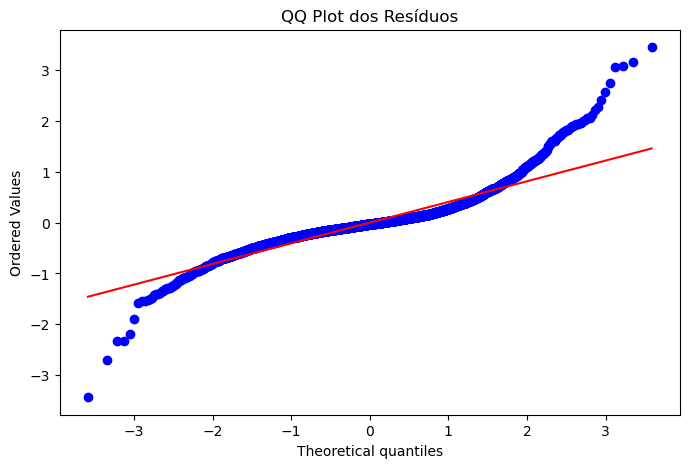

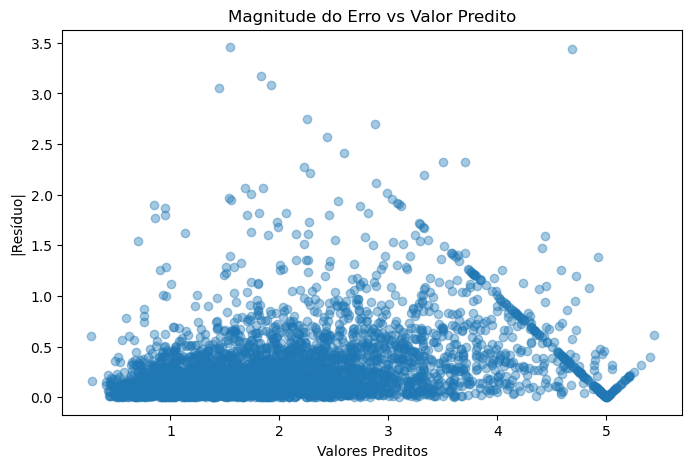


FIM DO DIAGNÓSTICO DOS RESÍDUOS


In [41]:
best_model = lgbm_search.best_estimator_
y_pred = best_model.predict(X_test)
res = y_test - y_pred

alpha = 0.05

print("\n" + "="*100)
print("DIAGNÓSTICO DOS RESÍDUOS")
print("="*100)

alpha = 0.05

# ==========================================================
# 1. JARQUE-BERA
# ==========================================================

jb_stat, jb_pvalue = jarque_bera(res)

print("\n[1] Jarque-Bera — Normalidade dos Resíduos")
print("-"*100)
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.6f}")

if jb_pvalue < alpha:
    print(
        "Conclusão: Rejeita H₀ → resíduos não seguem normalidade "
        "(comum em modelos baseados em árvores)."
    )
else:
    print(
        "Conclusão: Não rejeita H₀ → resíduos aproximadamente normais."
    )

# ==========================================================
# 2. ESTATÍSTICAS DESCRITIVAS
# ==========================================================

print("\n[2] Estatísticas dos Resíduos")
print("-"*100)

print(f"Média      : {res.mean():.6f}")
print(f"Mediana    : {np.median(res):.6f}")
print(f"Desvio Pad.: {res.std():.6f}")
print(f"Mínimo     : {res.min():.6f}")
print(f"Máximo     : {res.max():.6f}")

# ==========================================================
# 3. RESÍDUOS VS PREDITOS
# ==========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    res,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores Preditos")

plt.show()

# ==========================================================
# 4. HISTOGRAMA DOS RESÍDUOS
# ==========================================================

plt.figure(figsize=(8, 5))

plt.hist(
    res,
    bins=40
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")

plt.show()

# ==========================================================
# 5. QQ-PLOT
# ==========================================================

plt.figure(figsize=(8, 5))

stats.probplot(
    res,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot dos Resíduos")

plt.show()

# ==========================================================
# 6. RESÍDUO ABSOLUTO VS PREDITOS
# ==========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    np.abs(res),
    alpha=0.4
)

plt.xlabel("Valores Preditos")
plt.ylabel("|Resíduo|")
plt.title("Magnitude do Erro vs Valor Predito")

plt.show()

print("\n" + "="*100)
print("FIM DO DIAGNÓSTICO DOS RESÍDUOS")
print("="*100)

* Shap summary

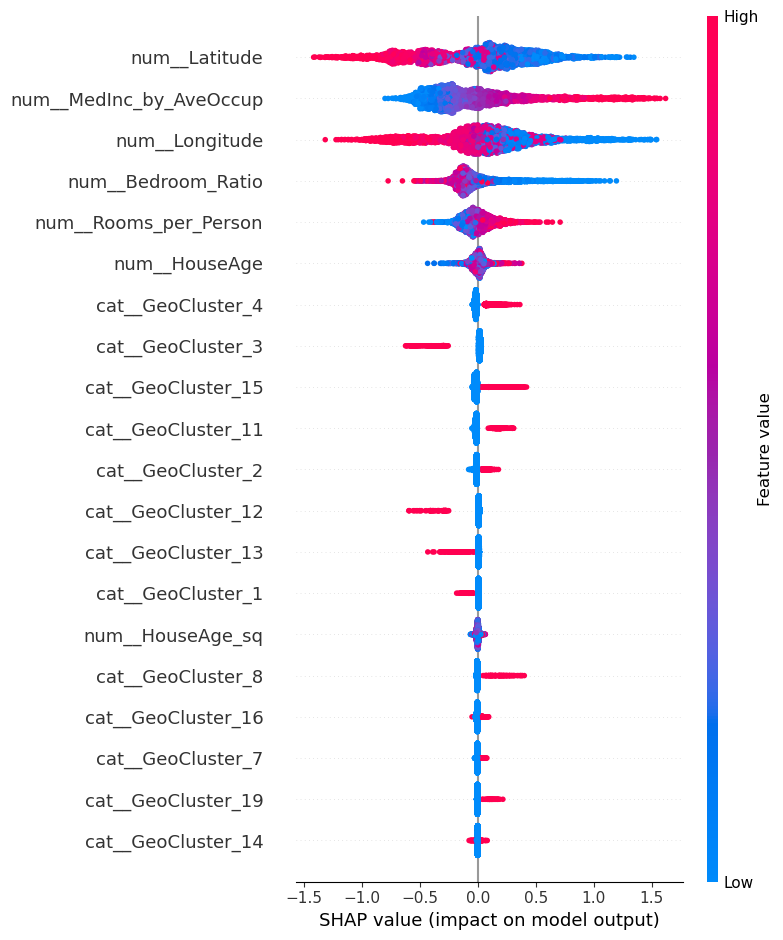

In [46]:
# Dados transformados pelo pipeline
X_transformed = best_model.named_steps["preprocess"].transform(X_test)

# Converter sparse matrix para matriz densa
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# Nomes das features após preprocessamento
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

# Converter para DataFrame
X_shap = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

# ==========================================================
# MODELO E SHAP
# ==========================================================

model = best_model.named_steps["model"]

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

# ==========================================================
# SUMMARY PLOT
# ==========================================================

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20
)

* Shap waterfall

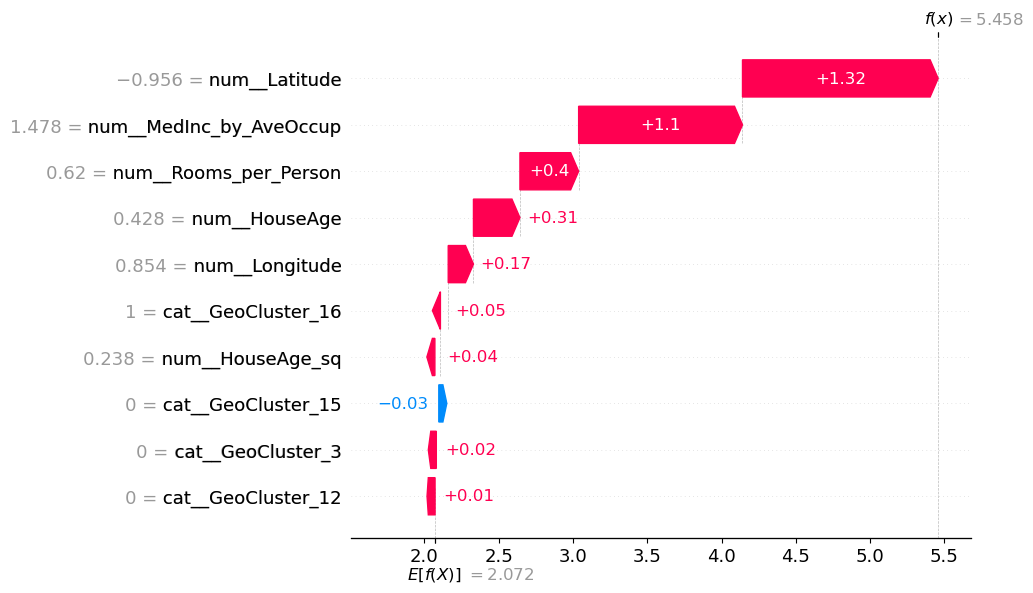

In [49]:
i = np.argmax(y_pred)
TOP_K = 10

shap_i = shap_values[i]
x_i = X_transformed[i]

top_idx = np.argsort(np.abs(shap_i))[-TOP_K:]

shap_i_top = shap_i[top_idx]
x_i_top = x_i[top_idx]
feature_names_top = np.array(feature_names)[top_idx]

# ordenar por importância para melhorar leitura
order = np.argsort(np.abs(shap_i_top))

shap_i_top = shap_i_top[order]
x_i_top = x_i_top[order]
feature_names_top = feature_names_top[order]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_i_top,
        base_values=explainer.expected_value,
        data=x_i_top,
        feature_names=feature_names_top
    )
)

# Síntese